In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
import torch
import transformers
from transformers import AutoModelForSequenceClassification,AutoTokenizer
from transformers import DataCollatorWithPadding,get_scheduler
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import evaluate


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Current device : ",device)

Current device :  cuda


In [ ]:
raw_dataset = load_dataset('glue','mrpc')
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize(data):
  return tokenizer(data['sentence1'],data['sentence2'],truncation=True)

tokenized_dataset = raw_dataset.map(tokenize,batched=True)
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset = tokenized_dataset.remove_columns(['sentence1','sentence2'])
tokenized_dataset.set_format('torch')
tokenized_dataset['train'].column_names

['label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask']

In [ ]:
train_loader = DataLoader(
    tokenized_dataset['train'],shuffle = True, batch_size = 8, collate_fn = data_collator
)

eval_loader = DataLoader(
    tokenized_dataset['validation'], batch_size = 8, collate_fn = data_collator
)

In [ ]:
for batch in train_loader:
  break
{k:v.shape for k,v in batch.items()}


{'idx': torch.Size([8]),
 'input_ids': torch.Size([8, 59]),
 'token_type_ids': torch.Size([8, 59]),
 'attention_mask': torch.Size([8, 59]),
 'labels': torch.Size([8])}

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint,num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
outputs = model(**batch)
print(outputs.loss,outputs.logits.shape)

tensor(0.6758, grad_fn=<NllLossBackward0>) torch.Size([8, 2])


In [ ]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(),lr=5e-5)

In [ ]:
epochs = 3
num_training_steps = epochs * len(train_loader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer = optimizer,
    num_warmup_steps = 0,
    num_training_steps = num_training_steps
)


In [ ]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
progress_bar = tqdm(range(num_training_steps))
model.train()
for epoch in range(epochs):
  for batch in train_loader:
    optimizer.zero_grad()
    batch = {k:v.to(device) for k,v in batch.items()}
    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    lr_scheduler.step()
    progress_bar.update(1)

  0%|          | 0/1377 [00:00<?, ?it/s]

In [ ]:
metric = evaluate.load("glue","mrpc")
model.eval()

for batch in eval_loader:
  batch = {k:v.to(device) for k,v in batch.items()}
  with torch.no_grad():
    outputs = model(**batch)

  logits = outputs.logits
  predictions = torch.argmax(logits,dim=1)
  metric.add_batch(predictions=predictions,references=batch['labels'])
metric.compute()

{'accuracy': 0.8602941176470589, 'f1': 0.9015544041450777}

In [ ]:
import requests

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

In [ ]:
image_url = "/content/rejected_55.jpg"
image = Image.open(image_url)

text = "an idol. a letter. a man."

inputs = processor(images=image, text=text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    text_threshold=0.3,
    target_sizes=[image.size[::-1]]
)


In [ ]:
results

[{'scores': tensor([0.3399, 0.2888, 0.2713, 0.2622, 0.2731, 0.2535, 0.2771, 0.2732, 0.2644,
          0.2789]),
  'boxes': tensor([[ 463.8378, 1114.0367,  813.3533, 1655.8275],
          [ 107.0930, 2216.9441,  198.8811, 2308.5679],
          [1087.8164, 2331.6831, 1180.6855, 2388.6675],
          [ 168.1853,   21.8474,  687.4454,  491.5695],
          [1210.6523, 2018.2703, 1277.5148, 2069.6672],
          [ 668.8200,   57.3619, 1227.2546,  598.3515],
          [1000.3749, 2029.5416, 1067.7814, 2076.8264],
          [ 735.5509, 1122.8792,  834.6379, 1239.3237],
          [ 674.1028,  428.1286,  723.4857,  475.6901],
          [ 504.8956, 1155.8864,  795.7369, 1591.6331]]),
  'text_labels': ['an idol', '', '', '', '', '', '', '', '', ''],
  'labels': ['an idol', '', '', '', '', '', '', '', '', '']}]

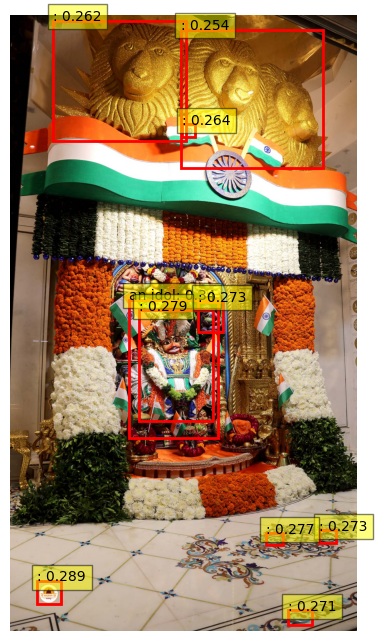

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_results(image, results):
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    ax = plt.gca()

    result = results[0]

    for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
        box = box.tolist()
        score = round(score.item(), 3)

        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        plt.text(box[0], box[1], f"{label},
                 bbox=dict(facecolor='yellow', alpha=0.5))

    plt.axis("off")
    plt.show()

plot_results(image, results)